In [ ]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_2d import Tile2Symb2dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2Symb2dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: -0.0095 | Max: 0.0485 | Mean: 0.0199 | Std: 0.0201
Min: 0.0313 | Max: 0.1120 | Mean: 0.0822 | Std: 0.0256
Min: 0.0386 | Max: 0.1705 | Mean: 0.0910 | Std: 0.0408
Min: 0.0385 | Max: 0.1730 | Mean: 0.1002 | Std: 0.0383
Min: 0.0281 | Max: 0.1832 | Mean: 0.0890 | Std: 0.0455
Min: 0.0428 | Max: 0.1977 | Mean: 0.0984 | Std: 0.0440
Min: 0.0404 | Max: 0.2098 | Mean: 0.1028 | Std: 0.0464
Min: 0.0387 | Max: 0.2009 | Mean: 0.1082 | Std: 0.0465
Min: 0.0454 | Max: 0.2093 | Mean: 0.1090 | Std: 0.0474


C:\Users\wojte\AppData\Local\Temp\ipykernel_16612\2571842847.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


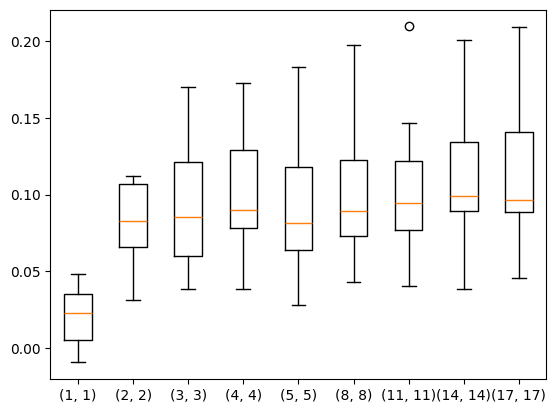

In [2]:
# bins

params_space = [
    (bins, bins) for bins in range(1, 5, 1)
]
params_space += [
    (bins, bins) for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: -0.0032 | Max: 0.1311 | Mean: 0.0582 | Std: 0.0345
Min: 0.0073 | Max: 0.1723 | Mean: 0.0884 | Std: 0.0421
Min: 0.0517 | Max: 0.2483 | Mean: 0.1221 | Std: 0.0506
Min: 0.0618 | Max: 0.2655 | Mean: 0.1403 | Std: 0.0529
Min: 0.0718 | Max: 0.2800 | Mean: 0.1544 | Std: 0.0552


C:\Users\wojte\AppData\Local\Temp\ipykernel_16612\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


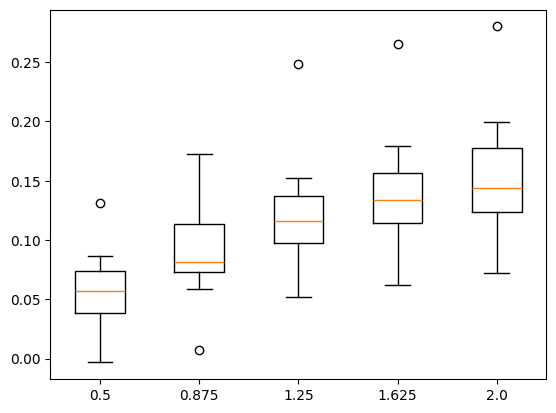

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [4]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2Symb2dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    win_w = math.ceil(MAX_WIDTH / img.width)
    win_h = win_w * 2
    if MAX_WIDTH:
        scale_w = MAX_WIDTH * win_w / img.width
    if MAX_HEIGHT:
        scale_h = MAX_HEIGHT * win_h / img.height
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    res_arr = converter.process_image(img, (win_w, win_h))
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------------
 | ~~=r1i<c+z}nv=\(}{j>;|//;-  | tDM%NRQm@2(tMOHQNMMMMR3bMMD | 
 | ;;;;;;;;|<___::.,_-`        | iCCiI4D#@Gi\D29NMKK5%DlYMl~ | 
 | @8NNNMMMMMMNNNNNNNNNQ&B&HHk | ~~//jE&HWE3-r''?lS];/(\|\<; | 
 | WWNNNNNNM$NNNNNNNNNNNNNNW@X | +nAGGHNW3''~'   ~)([3]3GGj( | 
 | W&NNMMN~-_~~7NNNNNNNNNNR0WD | [[]33EW&8U;     -EGXGGGHOEi | 
 | WRNNMRAeGWGA2NNNNNBQHH&8Wb4 | izkGAh$@8b]_ :  -d4DSEG(J)1 | 
 | 6880RNNNNNNNNNNNNNNNNWW@DEZ | |[]Z[X#W6@U\  : _GGG46DHk[/ | 
 | NNNNMMMNNMMMMMMMMMNNN@@WU43 | zG3Z34W@8@E<   ;J"'~3SZ29S3 | 
 | NNMMMMMMMMMMMMMNNNN08N8DUX3 | 33]{tFO9#8D1.,|Z+:-.~~J[]Li | 
---------------------------------------------------------------
 | VS99#2?~-~-_;nnv{)<nkW9T~-. |       :-:    | 
 | /><r/\____||(t1!!~~''--``-` | _;;;;;;;;;;_ | 
 | )())|<>>>c>/|+vv</\____;_;; | ]3]SXXG3[]][ | 
 | ii)(3V!2D4O@MMNKKkcvHHN$NNS | Z2ZZZSZVXZ2S | 
 | )(1l(~?3FSCiCUG[3SSZYf'=UF? | hhXh())~ZEXX | 
 | ())((<_ :`~r)C7??r=i\/;'^   | hhhE/`` !hE] | 
 |